In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import seaborn as sns

import torch
from torch import nn, Tensor

# Dataset SetUp

In [2]:
data = np.load("DrellYan.npz")
data_H = np.load("Higgs.npz")

taus = data["x_taus"]        # shape (N, 2, 18)
tauprod = data["x_tauprod"]  # shape (N, 10, 10)
met = data["x_met"]          # shape (N, 1, 8)
jets = data["x_jets"]        # shape (N, 3, 4)

target = data["target"]      # (N, 2, 1) gen-level log(pt) of taus
m_reco = data["inv_mass_reco"]  # (N,)
m_target = data["inv_mass_tar"] # (N,)


taus_H   = data_H["x_taus"]          # (N, 2, 18)
tauprod_H = data_H["x_tauprod"]      # (N, 10, 10)
met_H    = data_H["x_met"]           # (N, 1, 8)
jets_H   = data_H["x_jets"]          # (N, 3, 4)

target_H = data_H["target"]          # (N, 2, 1)
m_reco_H  = data_H["inv_mass_reco"]   # (N,)
m_target_H = data_H["inv_mass_tar"]   # (N,)

In [3]:
df = pd.DataFrame({
    "tau1_logpt": taus[:,0,0],
    "tau1_eta":   taus[:,0,1],
    "tau1_phi":   taus[:,0,2],
    "tau1_mass":  taus[:,0,3],
    "tau1_dxy":   taus[:,0,4],
    "tau1_dz":    taus[:,0,5],
    "tau1_ptCorrPNet": taus[:,0,6],
    "tau1_rawPNetVSjet": taus[:,0,7],
    "tau1_rawDeepTau2018v2p5VSjet": taus[:,0,8],
    "tau1_charge": taus[:,0,9],
    
    # decay mode indicator columns 
    "tau1_dM_0":  taus[:,0,10],
    "tau1_dM_1":  taus[:,0,11],
    "tau1_dM_2":  taus[:,0,12],
    "tau1_dM_10": taus[:,0,13],
    "tau1_dM_11": taus[:,0,14],
    
    "tau1_leadTkDeltaEta": taus[:,0,15],
    "tau1_leadTkDeltaPhi": taus[:,0,16],
    "tau1_leadTkPtOverTauPt": taus[:,0,17],

    "tau2_logpt": taus[:,1,0],
    "tau2_eta":   taus[:,1,1],
    "tau2_phi":   taus[:,1,2],
    "tau2_mass":  taus[:,1,3],
    "tau2_dxy":   taus[:,1,4],
    "tau2_dz":    taus[:,1,5],
    "tau2_ptCorrPNet": taus[:,1,6],
    "tau2_rawPNetVSjet": taus[:,1,7],
    "tau2_rawDeepTau2018v2p5VSjet": taus[:,1,8],
    "tau2_charge": taus[:,1,9],

    "tau2_dM_0":  taus[:,1,10],
    "tau2_dM_1":  taus[:,1,11],
    "tau2_dM_2":  taus[:,1,12],
    "tau2_dM_10": taus[:,1,13],
    "tau2_dM_11": taus[:,1,14],

    "tau2_leadTkDeltaEta": taus[:,1,15],
    "tau2_leadTkDeltaPhi": taus[:,1,16],
    "tau2_leadTkPtOverTauPt": taus[:,1,17],

    "gen_tau1_logpt": target[:,0,0],
    "gen_tau2_logpt": target[:,1,0],

    "inv_mass_reco": m_reco,
    "inv_mass_tar":  m_target,
})


df_H = pd.DataFrame({
    "tau1_logpt": taus_H[:,0,0],
    "tau1_eta":   taus_H[:,0,1],
    "tau1_phi":   taus_H[:,0,2],
    "tau1_mass":  taus_H[:,0,3],
    "tau1_dxy":   taus_H[:,0,4],
    "tau1_dz":    taus_H[:,0,5],
    "tau1_ptCorrPNet": taus_H[:,0,6],
    "tau1_rawPNetVSjet": taus_H[:,0,7],
    "tau1_rawDeepTau2018v2p5VSjet": taus_H[:,0,8],
    "tau1_charge": taus_H[:,0,9],
    
    # decay mode indicator columns (same as DY)
    "tau1_dM_0":  taus_H[:,0,10],
    "tau1_dM_1":  taus_H[:,0,11],
    "tau1_dM_2":  taus_H[:,0,12],
    "tau1_dM_10": taus_H[:,0,13],
    "tau1_dM_11": taus_H[:,0,14],
    
    "tau1_leadTkDeltaEta": taus_H[:,0,15],
    "tau1_leadTkDeltaPhi": taus_H[:,0,16],
    "tau1_leadTkPtOverTauPt": taus_H[:,0,17],

    "tau2_logpt": taus_H[:,1,0],
    "tau2_eta":   taus_H[:,1,1],
    "tau2_phi":   taus_H[:,1,2],
    "tau2_mass":  taus_H[:,1,3],
    "tau2_dxy":   taus_H[:,1,4],
    "tau2_dz":    taus_H[:,1,5],
    "tau2_ptCorrPNet": taus_H[:,1,6],
    "tau2_rawPNetVSjet": taus_H[:,1,7],
    "tau2_rawDeepTau2018v2p5VSjet": taus_H[:,1,8],
    "tau2_charge": taus_H[:,1,9],

    "tau2_dM_0":  taus_H[:,1,10],
    "tau2_dM_1":  taus_H[:,1,11],
    "tau2_dM_2":  taus_H[:,1,12],
    "tau2_dM_10": taus_H[:,1,13],
    "tau2_dM_11": taus_H[:,1,14],

    "tau2_leadTkDeltaEta": taus_H[:,1,15],
    "tau2_leadTkDeltaPhi": taus_H[:,1,16],
    "tau2_leadTkPtOverTauPt": taus_H[:,1,17],

    "gen_tau1_logpt": target_H[:,0,0],
    "gen_tau2_logpt": target_H[:,1,0],

    "inv_mass_reco": m_reco_H,
    "inv_mass_tar":  m_target_H,
})


In [4]:
# Per la matrice di correlazione :
jet_features = ['logpt', 'eta', 'phi', 'mass']

met_features = [
    'MET_logpt', 'MET_phi', 'MET_covXX', 'MET_covXY',
    'MET_covYY', 'MET_significance', 'MET_sumEt', 'MET_sumPtUnclustered'
]

df["jet1_logpt"] = jets[:,0,0]
df["jet1_eta"]   = jets[:,0,1]
df["jet1_phi"]   = jets[:,0,2]
df["jet1_mass"]  = jets[:,0,3]

df["jet2_logpt"] = jets[:,1,0]
df["jet2_eta"]   = jets[:,1,1]
df["jet2_phi"]   = jets[:,1,2]
df["jet2_mass"]  = jets[:,1,3]

df["jet3_logpt"] = jets[:,2,0]
df["jet3_eta"]   = jets[:,2,1]
df["jet3_phi"]   = jets[:,2,2]
df["jet3_mass"]  = jets[:,2,3]


met_features = [
    "MET_logpt","MET_phi","MET_covXX","MET_covXY",
    "MET_covYY","MET_significance","MET_sumEt","MET_sumPtUnclustered"
]

for i, name in enumerate(met_features):
    df[name] = met[:,0,i]




df_H["jet1_logpt"] = jets_H[:,0,0]
df_H["jet1_eta"]   = jets_H[:,0,1]
df_H["jet1_phi"]   = jets_H[:,0,2]
df_H["jet1_mass"]  = jets_H[:,0,3]

df_H["jet2_logpt"] = jets_H[:,1,0]
df_H["jet2_eta"]   = jets_H[:,1,1]
df_H["jet2_phi"]   = jets_H[:,1,2]
df_H["jet2_mass"]  = jets_H[:,1,3]

df_H["jet3_logpt"] = jets_H[:,2,0]
df_H["jet3_eta"]   = jets_H[:,2,1]
df_H["jet3_phi"]   = jets_H[:,2,2]
df_H["jet3_mass"]  = jets_H[:,2,3]


for i, name in enumerate(met_features):
    df_H[name] = met_H[:,0,i]

In [5]:
df["tau1_pt_reco"] = np.exp(df["tau1_logpt"])
df["tau2_pt_reco"] = np.exp(df["tau2_logpt"])

df["tau1_pt_gen"] = df["gen_tau1_logpt"]
df["tau2_pt_gen"] = df["gen_tau2_logpt"]


df_H["tau1_pt_reco"] = np.exp(df_H["tau1_logpt"])
df_H["tau2_pt_reco"] = np.exp(df_H["tau2_logpt"])

df_H["tau1_pt_gen"] = df_H["gen_tau1_logpt"]
df_H["tau2_pt_gen"] = df_H["gen_tau2_logpt"]

df["tau1_ptreco_over_ptgen"] = df["tau1_pt_reco"]/df["tau1_pt_gen"]
df["tau2_ptreco_over_ptgen"] = df["tau2_pt_reco"]/df["tau2_pt_gen"]

df_H["tau1_ptreco_over_ptgen"] = df_H["tau1_pt_reco"]/df_H["tau1_pt_gen"]
df_H["tau2_ptreco_over_ptgen"] = df_H["tau2_pt_reco"]/df_H["tau2_pt_gen"]

In [6]:
log_pt_min = np.log(30.0)   # ~3.401

mask_pt = (df["tau1_logpt"] > log_pt_min) & (df["tau2_logpt"] > log_pt_min)

print("Eventi totali:", len(df))
print("Eventi che passano pT>30 GeV (in log):", mask_pt.sum())

df_sel = df[mask_pt].copy()

mask_pt_H = (df_H["tau1_logpt"] > log_pt_min) & (df_H["tau2_logpt"] > log_pt_min)

print("Eventi totali:", len(df_H))
print("Eventi che passano pT>30 GeV (in log):", mask_pt_H.sum())

df_H_sel = df_H[mask_pt_H].copy()

Eventi totali: 335263
Eventi che passano pT>30 GeV (in log): 69198
Eventi totali: 355225
Eventi che passano pT>30 GeV (in log): 158632


In [7]:
df_sel["tau1_abs_eta"] = df_sel["tau1_eta"].abs()
df_sel["tau2_abs_eta"] = df_sel["tau2_eta"].abs()

df_sel["tau1_is_barrel"] = df_sel["tau1_abs_eta"] < 1.4
df_sel["tau1_is_endcap"] = ~df_sel["tau1_is_barrel"]

df_sel["tau2_is_barrel"] = df_sel["tau2_abs_eta"] < 1.4
df_sel["tau2_is_endcap"] = ~df_sel["tau2_is_barrel"]


df_H_sel["tau1_abs_eta"] = df_H_sel["tau1_eta"].abs()
df_H_sel["tau2_abs_eta"] = df_H_sel["tau2_eta"].abs()

df_H_sel["tau1_is_barrel"] = df_H_sel["tau1_abs_eta"] < 1.4
df_H_sel["tau1_is_endcap"] = ~df_H_sel["tau1_is_barrel"]

df_H_sel["tau2_is_barrel"] = df_H_sel["tau2_abs_eta"] < 1.4
df_H_sel["tau2_is_endcap"] = ~df_H_sel["tau2_is_barrel"]

In [8]:
summary = pd.DataFrame({
    "Process": ["Drell–Yan", "Higgs"],
    "Total events": [len(df), len(df_H)],
    "After pT>30 GeV cut": [mask_pt.sum(), mask_pt_H.sum()]
})

summary["Retention (%)"] = 100 * summary["After pT>30 GeV cut"] / summary["Total events"]
summary


,Process,Total events,After pT>30 GeV cut,Retention (%)
0,Drell–Yan,335263,69198,20.639916
1,Higgs,355225,158632,44.656767


In [9]:
# Plot m_reco, m_tar e risoluzione :

# DY (dopo taglio pT)
m_reco_DY    = df_sel["inv_mass_reco"].values
m_target_DY  = df_sel["inv_mass_tar"].values

# Higgs (dopo taglio pT)
m_reco_H     = df_H_sel["inv_mass_reco"].values
m_target_H   = df_H_sel["inv_mass_tar"].values

# Risoluzioni relative
res_DY = (m_reco_DY - m_target_DY) / m_target_DY
res_H  = (m_reco_H  - m_target_H) / m_target_H

In [10]:
df_sel["tau1_response"] = df_sel["tau1_pt_reco"] / df_sel["tau1_pt_gen"]
df_sel["tau1_resolution"] = (df_sel["tau1_pt_reco"] - df_sel["tau1_pt_gen"]) / df_sel["tau1_pt_gen"]

df_sel["tau2_response"] = df_sel["tau2_pt_reco"] / df_sel["tau2_pt_gen"]
df_sel["tau2_resolution"] = (df_sel["tau2_pt_reco"] - df_sel["tau2_pt_gen"]) / df_sel["tau2_pt_gen"]


df_H_sel["tau1_response"] = df_H_sel["tau1_pt_reco"] / df_H_sel["tau1_pt_gen"]
df_H_sel["tau1_resolution"] = (df_H_sel["tau1_pt_reco"] - df_H_sel["tau1_pt_gen"]) / df_H_sel["tau1_pt_gen"]

df_H_sel["tau2_response"] = df_H_sel["tau2_pt_reco"] / df_H_sel["tau2_pt_gen"]
df_H_sel["tau2_resolution"] = (df_H_sel["tau2_pt_reco"] - df_H_sel["tau2_pt_gen"]) / df_H_sel["tau2_pt_gen"]

# pT corretta con PNet
df_sel["tau1_pt_reco_corrPNet"] = df_sel["tau1_pt_reco"] * df_sel["tau1_ptCorrPNet"]
df_sel["tau2_pt_reco_corrPNet"] = df_sel["tau2_pt_reco"] * df_sel["tau2_ptCorrPNet"]

# response corretta
df_sel["tau1_response_corrPNet"] = df_sel["tau1_pt_reco_corrPNet"] / df_sel["tau1_pt_gen"]
df_sel["tau2_response_corrPNet"] = df_sel["tau2_pt_reco_corrPNet"] / df_sel["tau2_pt_gen"]


# pT corretta con PNet
df_H_sel["tau1_pt_reco_corrPNet"] = df_H_sel["tau1_pt_reco"] * df_H_sel["tau1_ptCorrPNet"]
df_H_sel["tau2_pt_reco_corrPNet"] = df_H_sel["tau2_pt_reco"] * df_H_sel["tau2_ptCorrPNet"]

# response corretta
df_H_sel["tau1_response_corrPNet"] = df_H_sel["tau1_pt_reco_corrPNet"] / df_H_sel["tau1_pt_gen"]
df_H_sel["tau2_response_corrPNet"] = df_H_sel["tau2_pt_reco_corrPNet"] / df_H_sel["tau2_pt_gen"]


In [11]:
dm_map = {
    "dM_0": 0, "dM_1": 1, "dM_2": 2,
    "dM_10": 10, "dM_11": 11
}

dm_values = [0, 1, 2, 10, 11]

dm_labels = {
    0: "DM 0 (1-prong, 0 π0)",
    1: "DM 1 (1-prong, 1 π0)",
    2: "DM 2 (1-prong, 2 π0)",
    10: "DM 10 (3-prong, 0 π0)",
    11: "DM 11 (3-prong, 1 π0)",
}


# DY
df_sel["tau1_dm"] = (
      df_sel["tau1_dM_0"]  * 0
    + df_sel["tau1_dM_1"]  * 1
    + df_sel["tau1_dM_2"]  * 2
    + df_sel["tau1_dM_10"] * 10
    + df_sel["tau1_dM_11"] * 11
)

df_sel["tau2_dm"] = (
      df_sel["tau2_dM_0"]  * 0
    + df_sel["tau2_dM_1"]  * 1
    + df_sel["tau2_dM_2"]  * 2
    + df_sel["tau2_dM_10"] * 10
    + df_sel["tau2_dM_11"] * 11
)

# Higgs
df_H_sel["tau1_dm"] = (
      df_H_sel["tau1_dM_0"]  * 0
    + df_H_sel["tau1_dM_1"]  * 1
    + df_H_sel["tau1_dM_2"]  * 2
    + df_H_sel["tau1_dM_10"] * 10
    + df_H_sel["tau1_dM_11"] * 11
)

df_H_sel["tau2_dm"] = (
      df_H_sel["tau2_dM_0"]  * 0
    + df_H_sel["tau2_dM_1"]  * 1
    + df_H_sel["tau2_dM_2"]  * 2
    + df_H_sel["tau2_dM_10"] * 10
    + df_H_sel["tau2_dM_11"] * 11
)

In [12]:
# definizioni utili
# ----- DY -----
df_sel["tau1_response"]   = df_sel["tau1_pt_reco"] / df_sel["tau1_pt_gen"]
df_sel["tau2_response"]   = df_sel["tau2_pt_reco"] / df_sel["tau2_pt_gen"]

df_sel["tau1_resolution"] = df_sel["tau1_response"] - 1.0
df_sel["tau2_resolution"] = df_sel["tau2_response"] - 1.0

# PNet-corrected pT
df_sel["tau1_pt_reco_corrPNet"] = df_sel["tau1_pt_reco"] * df_sel["tau1_ptCorrPNet"]
df_sel["tau2_pt_reco_corrPNet"] = df_sel["tau2_pt_reco"] * df_sel["tau2_ptCorrPNet"]

# PNet-corrected response
df_sel["tau1_response_corrPNet"] = df_sel["tau1_pt_reco_corrPNet"] / df_sel["tau1_pt_gen"]
df_sel["tau2_response_corrPNet"] = df_sel["tau2_pt_reco_corrPNet"] / df_sel["tau2_pt_gen"]

df_sel["tau1_resolution_corrPNet"] = df_sel["tau1_response_corrPNet"] - 1.0
df_sel["tau2_resolution_corrPNet"] = df_sel["tau2_response_corrPNet"] - 1.0


# ----- HIGGS -----
df_H_sel["tau1_response"]   = df_H_sel["tau1_pt_reco"] / df_H_sel["tau1_pt_gen"]
df_H_sel["tau2_response"]   = df_H_sel["tau2_pt_reco"] / df_H_sel["tau2_pt_gen"]

df_H_sel["tau1_resolution"] = df_H_sel["tau1_response"] - 1.0
df_H_sel["tau2_resolution"] = df_H_sel["tau2_response"] - 1.0

# PNet-corrected pT
df_H_sel["tau1_pt_reco_corrPNet"] = df_H_sel["tau1_pt_reco"] * df_H_sel["tau1_ptCorrPNet"]
df_H_sel["tau2_pt_reco_corrPNet"] = df_H_sel["tau2_pt_reco"] * df_H_sel["tau2_ptCorrPNet"]

# PNet-corrected response
df_H_sel["tau1_response_corrPNet"] = df_H_sel["tau1_pt_reco_corrPNet"] / df_H_sel["tau1_pt_gen"]
df_H_sel["tau2_response_corrPNet"] = df_H_sel["tau2_pt_reco_corrPNet"] / df_H_sel["tau2_pt_gen"]

df_H_sel["tau1_resolution_corrPNet"] = df_H_sel["tau1_response_corrPNet"] - 1.0
df_H_sel["tau2_resolution_corrPNet"] = df_H_sel["tau2_response_corrPNet"] - 1.0


# $\tau$ ID

In [13]:
# ================================
# EVENT-LEVEL VALID — Drell–Yan
# (tengo solo eventi con tau1 e tau2 validi)
# ================================

df_sel_valid = df_sel[
    (df_sel["tau1_rawPNetVSjet"] != -1) &
    (df_sel["tau2_rawPNetVSjet"] != -1)
].copy()

print("DY valid events =", len(df_sel_valid))


# ================================
# EVENT-LEVEL VALID — Higgs
# ================================

df_H_sel_valid = df_H_sel[
    (df_H_sel["tau1_rawPNetVSjet"] != -1) &
    (df_H_sel["tau2_rawPNetVSjet"] != -1)
].copy()

print("Higgs valid events =", len(df_H_sel_valid))


DY valid events = 68774
Higgs valid events = 157892


In [14]:
df_sel_tau1_valid = df_sel_valid.copy()
df_sel_tau2_valid = df_sel_valid.copy()

df_H_sel_tau1_valid = df_H_sel_valid.copy()
df_H_sel_tau2_valid = df_H_sel_valid.copy()

print("\nCheck lengths:")
print("DY:", len(df_sel_tau1_valid), len(df_sel_tau2_valid))
print("H :", len(df_H_sel_tau1_valid), len(df_H_sel_tau2_valid))



Check lengths:
DY: 68774 68774
H : 157892 157892


In [15]:
def find_threshold_for_efficiency(thresholds, efficiencies, target_eff=0.90):
    """
    Trova la soglia il cui valore di efficienza è più vicino a target_eff.
    """
    idx = np.argmin(np.abs(efficiencies - target_eff))
    return thresholds[idx], efficiencies[idx]

target_eff = 0.90


# ================================================
# TAU1 — HIGGS (event-level sample)
# ================================================
vals_tau1 = df_H_sel_valid["tau1_rawPNetVSjet"].values

# soglie possibili
thresholds_tau1 = np.sort(np.unique(vals_tau1))

# efficienza: P(rawPNet > thr)
eff_tau1 = np.array([
    np.mean(vals_tau1 > thr) for thr in thresholds_tau1
])

thr_tau1, eff_at_thr_tau1 = find_threshold_for_efficiency(
    thresholds_tau1, eff_tau1, target_eff
)

print(f"[Higgs] Tau1: soglia = {thr_tau1:.6f}, efficienza ≈ {eff_at_thr_tau1:.4f}")


# ================================================
# TAU2 — HIGGS (event-level sample)
# ================================================
vals_tau2 = df_H_sel_valid["tau2_rawPNetVSjet"].values

thresholds_tau2 = np.sort(np.unique(vals_tau2))

eff_tau2 = np.array([
    np.mean(vals_tau2 > thr) for thr in thresholds_tau2
])

thr_tau2, eff_at_thr_tau2 = find_threshold_for_efficiency(
    thresholds_tau2, eff_tau2, target_eff
)

print(f"[Higgs] Tau2: soglia = {thr_tau2:.6f}, efficienza ≈ {eff_at_thr_tau2:.4f}")


[Higgs] Tau1: soglia = 0.642090, efficienza ≈ 0.9000
[Higgs] Tau2: soglia = 0.495850, efficienza ≈ 0.9000


In [16]:
# ============================
# HIGGS: applico le soglie (EVENT-LEVEL)
# ============================

mask_H_tau1 = df_H_sel_valid["tau1_rawPNetVSjet"] > thr_tau1
mask_H_tau2 = df_H_sel_valid["tau2_rawPNetVSjet"] > thr_tau2
mask_H_evt  = mask_H_tau1 & mask_H_tau2

df_H_sel_tauID = df_H_sel_valid[mask_H_evt].copy()

# efficienza event-level (questa è quella “giusta”)
eff_H_evt = mask_H_evt.mean() if len(df_H_sel_valid) > 0 else float("nan")

print("[Higgs] efficienze con soglie (event-level AND):")
print(f"  eventi (tau1 & tau2): {eff_H_evt:.4f}")

# diagnostica: efficienze “oggetto” sullo stesso sample di eventi validi
eff_H_tau1_obj = mask_H_tau1.mean() if len(df_H_sel_valid) > 0 else float("nan")
eff_H_tau2_obj = mask_H_tau2.mean() if len(df_H_sel_valid) > 0 else float("nan")
print("[Higgs] (oggetto, stesso sample):")
print(f"  tau1: {eff_H_tau1_obj:.4f}")
print(f"  tau2: {eff_H_tau2_obj:.4f}")


# ============================
# DY: applico le STESSE soglie (EVENT-LEVEL)
# ============================

mask_DY_tau1 = df_sel_valid["tau1_rawPNetVSjet"] > thr_tau1
mask_DY_tau2 = df_sel_valid["tau2_rawPNetVSjet"] > thr_tau2
mask_DY_evt  = mask_DY_tau1 & mask_DY_tau2

df_sel_tauID = df_sel_valid[mask_DY_evt].copy()

eff_DY_evt = mask_DY_evt.mean() if len(df_sel_valid) > 0 else float("nan")

print("\n[DY] efficienze risultanti con soglie fissate da Higgs (event-level AND):")
print(f"  eventi (tau1 & tau2): {eff_DY_evt:.4f}")

# diagnostica: oggetto
eff_DY_tau1_obj = mask_DY_tau1.mean() if len(df_sel_valid) > 0 else float("nan")
eff_DY_tau2_obj = mask_DY_tau2.mean() if len(df_sel_valid) > 0 else float("nan")
print("[DY] (oggetto, stesso sample):")
print(f"  tau1: {eff_DY_tau1_obj:.4f}")
print(f"  tau2: {eff_DY_tau2_obj:.4f}")



[Higgs] efficienze con soglie (event-level AND):
  eventi (tau1 & tau2): 0.8109
[Higgs] (oggetto, stesso sample):
  tau1: 0.9000
  tau2: 0.9000

[DY] efficienze risultanti con soglie fissate da Higgs (event-level AND):
  eventi (tau1 & tau2): 0.7477
[DY] (oggetto, stesso sample):
  tau1: 0.8526
  tau2: 0.8725


In [17]:
df_tauid_thresholds = pd.DataFrame({
    "Tau": ["Tau1", "Tau2"],
    "Threshold (rawPNet)": [thr_tau1, thr_tau2],
    "Target object efficiency (%)": [90.0, 90.0],
    "Higgs object efficiency (%)": [
        eff_H_tau1_obj * 100,
        eff_H_tau2_obj * 100
    ],
    "DY object efficiency (%)": [
        eff_DY_tau1_obj * 100,
        eff_DY_tau2_obj * 100
    ]
})

df_tauid_thresholds = df_tauid_thresholds.set_index("Tau")
df_tauid_thresholds


,Threshold (rawPNet),Target object efficiency (%),Higgs object efficiency (%),DY object efficiency (%)
Tau,,,,
Tau1,0.64209,90.0,90.003293,85.261872
Tau2,0.49585,90.0,90.004560,87.249542


In [18]:
df_DY_event = df_sel_tauID.copy()
df_H_event = df_H_sel_tauID.copy()

In [19]:
df_DY_event

,tau1_logpt,tau1_eta,tau1_phi,tau1_mass,tau1_dxy,tau1_dz,tau1_ptCorrPNet,tau1_rawPNetVSjet,tau1_rawDeepTau2018v2p5VSjet,tau1_charge,...,tau2_response,tau2_resolution,tau1_pt_reco_corrPNet,tau2_pt_reco_corrPNet,tau1_response_corrPNet,tau2_response_corrPNet,tau1_dm,tau2_dm,tau1_resolution_corrPNet,tau2_resolution_corrPNet
2,3.674162,0.875122,-0.090088,0.646484,-0.000050,0.000212,1.153320,0.914062,0.984863,-1.0,...,0.914873,-0.085127,45.458812,35.007927,0.974988,0.894771,1.0,10.0,-0.025012,-0.105229
6,3.694579,2.389160,1.977051,1.098633,-0.001568,0.005698,1.026367,0.996094,0.994629,1.0,...,0.850390,-0.149610,41.289354,41.035457,0.902500,0.901878,10.0,1.0,-0.097500,-0.098122
9,3.875156,-0.371704,0.386658,1.157227,0.000169,-0.001055,1.019531,0.999023,0.997559,-1.0,...,0.979220,-0.020780,49.131415,30.844352,0.929199,0.981132,10.0,1.0,-0.070801,-0.018868
17,3.964924,0.317871,1.018311,1.087891,-0.001331,-0.000872,0.998535,0.888672,0.994629,1.0,...,0.618578,-0.381422,52.639059,31.170514,0.929608,0.623410,1.0,0.0,-0.070392,-0.376590
25,3.511394,1.427734,0.866943,1.159180,0.000447,0.009053,0.967773,0.906738,0.992188,1.0,...,0.735075,-0.264925,32.415494,34.021892,0.743049,0.788913,1.0,10.0,-0.256951,-0.211087
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
335247,3.621049,0.668579,-1.771973,0.139526,0.001639,-0.000466,1.020508,0.988770,0.995605,-1.0,...,0.822673,-0.177327,38.143286,37.213682,0.833733,0.860432,0.0,0.0,-0.166267,-0.139568
335248,3.866463,0.207764,-0.460815,8.117188,0.030228,0.039980,0.803223,0.996582,-1.000000,-1.0,...,0.657699,-0.342301,38.372454,36.768819,0.730904,0.673113,1.0,0.0,-0.269096,-0.326887
335250,3.591280,0.836426,-0.882080,0.139526,-0.000064,0.000663,1.022461,0.869629,0.966797,-1.0,...,0.730076,-0.269924,37.095369,31.822474,0.893864,0.740058,0.0,10.0,-0.106136,-0.259942
335252,3.735802,-0.003489,-0.321960,7.296875,-0.002762,0.010244,0.840332,0.984863,-1.000000,-1.0,...,0.696674,-0.303326,35.228097,32.708994,0.924016,0.713003,1.0,10.0,-0.075984,-0.286997


In [20]:
df_H_event

,tau1_logpt,tau1_eta,tau1_phi,tau1_mass,tau1_dxy,tau1_dz,tau1_ptCorrPNet,tau1_rawPNetVSjet,tau1_rawDeepTau2018v2p5VSjet,tau1_charge,...,tau2_response,tau2_resolution,tau1_pt_reco_corrPNet,tau2_pt_reco_corrPNet,tau1_response_corrPNet,tau2_response_corrPNet,tau1_dm,tau2_dm,tau1_resolution_corrPNet,tau2_resolution_corrPNet
0,3.750918,0.149750,-2.504883,0.919922,0.001779,0.000654,1.097656,0.985840,0.997559,1.0,...,0.845754,-0.154246,46.716416,44.649644,0.836088,0.989466,1.0,1.0,-0.163912,-0.010534
1,3.908546,-0.357422,-2.585938,0.139526,0.006088,0.012403,0.971680,0.966797,0.997559,1.0,...,0.897412,-0.102588,48.415350,42.992980,0.780893,0.924580,0.0,0.0,-0.219107,-0.075420
6,3.735467,0.549683,1.355957,0.788574,0.002239,0.000944,1.020508,0.999023,0.999512,-1.0,...,0.818558,-0.181442,42.767043,31.457024,0.715766,0.830548,1.0,0.0,-0.284234,-0.169452
10,3.729789,0.430664,-0.860352,0.687012,0.011436,-0.025360,1.043945,0.988281,0.999512,1.0,...,0.531978,-0.468022,43.501531,38.147589,0.805584,0.544966,1.0,1.0,-0.194416,-0.455034
14,4.210932,1.539795,0.115631,8.835938,-0.506348,1.439453,0.895996,0.809082,-1.000000,1.0,...,0.586712,-0.413288,60.407485,38.603266,0.891623,0.630257,1.0,0.0,-0.108377,-0.369743
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
355215,4.048012,-0.148254,-0.296021,0.499023,0.006256,-0.002593,1.053711,0.997070,0.991211,1.0,...,0.647763,-0.352237,60.360228,43.611693,0.981467,0.758464,1.0,1.0,-0.018533,-0.241536
355216,3.832828,-1.078857,-1.057373,1.222656,-0.000417,-0.002056,1.019531,0.999023,0.994629,-1.0,...,0.816822,-0.183178,47.095196,35.609318,0.765776,0.802464,10.0,1.0,-0.234224,-0.197536
355217,4.351929,0.073349,-0.372009,13.562500,-0.004543,3.602661,0.901855,0.769531,-1.000000,-1.0,...,0.563180,-0.436820,70.009306,31.586895,0.952508,0.576930,2.0,1.0,-0.047492,-0.423070
355219,3.875998,0.232666,1.962646,5.148438,0.012688,0.028769,0.967773,0.999023,-1.000000,-1.0,...,0.722039,-0.277961,46.676508,41.002581,0.608163,0.805948,2.0,1.0,-0.391837,-0.194052


In [43]:
# Sistemo i nomi delle colonne sbagliate :
# ========= DY =========
df_DY_event = df_DY_event.copy()

# reco
df_DY_event["tau1_pt_reco"] = np.exp(df_DY_event["tau1_logpt"])
df_DY_event["tau2_pt_reco"] = np.exp(df_DY_event["tau2_logpt"])

# gen 
df_DY_event["tau1_pt_gen"] = df_DY_event["gen_tau1_logpt"]
df_DY_event["tau2_pt_gen"] = df_DY_event["gen_tau2_logpt"]

# ========= Higgs =========
df_H_event = df_H_event.copy()

df_H_event["tau1_pt_reco"] = np.exp(df_H_event["tau1_logpt"])
df_H_event["tau2_pt_reco"] = np.exp(df_H_event["tau2_logpt"])

df_H_event["tau1_pt_gen"] = df_H_event["gen_tau1_logpt"]
df_H_event["tau2_pt_gen"] = df_H_event["gen_tau2_logpt"]


# Model

### FASE 1 - Costruzione del modello:
    - CouplingMLP
    - ConditionalAffineCoupling
    - ConditionalRealNVP
    - build_flow()

### FASE 2 - Training del flow

### FASE 3 - Inferenza fisica

In [44]:
import time
import torch

from torch import nn, Tensor

from flow_matching.path.scheduler import CondOTScheduler
from flow_matching.path import AffineProbPath
from flow_matching.solver import Solver, ODESolver
from flow_matching.utils import ModelWrapper

import matplotlib.pyplot as plt

from matplotlib import cm

import warnings

warnings.filterwarnings("ignore", category=UserWarning, module='torch')

In [31]:
tau1_cols = [
    "tau1_logpt", "tau1_eta", "tau1_phi", "tau1_mass",
    "tau1_dxy", "tau1_dz",
    "tau1_ptCorrPNet", "tau1_rawPNetVSjet", "tau1_rawDeepTau2018v2p5VSjet",
    "tau1_charge",
    "tau1_dM_0", "tau1_dM_1", "tau1_dM_2", "tau1_dM_10", "tau1_dM_11",
    "tau1_leadTkDeltaEta", "tau1_leadTkDeltaPhi", "tau1_leadTkPtOverTauPt", 
    # "tau1_ptreco_over_ptgen",
 #   "gen_tau1_logpt"
]

tau2_cols = [
    "tau2_logpt", "tau2_eta", "tau2_phi", "tau2_mass",
    "tau2_dxy", "tau2_dz",
    "tau2_ptCorrPNet", "tau2_rawPNetVSjet", "tau2_rawDeepTau2018v2p5VSjet",
    "tau2_charge",
    "tau2_dM_0", "tau2_dM_1", "tau2_dM_2", "tau2_dM_10", "tau2_dM_11",
    "tau2_leadTkDeltaEta", "tau2_leadTkDeltaPhi", "tau2_leadTkPtOverTauPt", 
    # "tau2_ptreco_over_ptgen",
  #  "gen_tau2_logpt",
]

jet_cols = [
    "jet1_logpt", "jet1_eta", "jet1_phi", "jet1_mass",
    "jet2_logpt", "jet2_eta", "jet2_phi", "jet2_mass",
    "jet3_logpt", "jet3_eta", "jet3_phi", "jet3_mass",
]

met_cols = [
    "MET_logpt","MET_phi","MET_covXX","MET_covXY",
    "MET_covYY","MET_significance","MET_sumEt","MET_sumPtUnclustered"
]

# gen_cols = ["gen_tau1_logpt", "gen_tau2_logpt"]

# mass_cols = ["inv_mass_reco", "inv_mass_tar"]

class_col = ["class"]

df_DY_event["class"] = 0  
df_H_event["class"] = 1

In [32]:
met_cols_reduced = [
    "MET_logpt",
    "MET_phi",
    "MET_significance",
    "MET_sumEt",
]

In [33]:
train_cols = (
    tau1_cols
    + tau2_cols
    + jet_cols
    + met_cols_reduced
)

In [46]:
# Target: fattore di correzione

eps = 1e-8
for df in [df_DY_event, df_H_event]:
    df["tau1_corr"] = df["tau1_pt_gen"] / np.clip(df["tau1_pt_reco"], eps, None)
    df["tau2_corr"] = df["tau2_pt_gen"] / np.clip(df["tau2_pt_reco"], eps, None)

y_cols = ["tau1_corr", "tau2_corr"]


In [47]:
df_DY_event["class"] = 0
df_H_event["class"]  = 1
label_col = ["class"]


In [49]:
# Check

print(df_DY_event[y_cols].describe().loc[["mean","std","min","max"]])
print(df_H_event[y_cols].describe().loc[["mean","std","min","max"]])


      tau1_corr  tau2_corr
mean   1.182687   1.307418
std    0.242977   0.306200
min    0.513444   0.518520
max    7.388758  12.087224
      tau1_corr  tau2_corr
mean   1.317047   1.517179
std    0.336322   0.420126
min    0.521634   0.519532
max    8.048297  10.924113


In [51]:
SEED = 42

n_bal = min(len(df_DY_event), len(df_H_event))

df_DY_bal = df_DY_event.sample(n=n_bal, random_state=SEED)
df_H_bal  = df_H_event.sample(n=n_bal, random_state=SEED)

df_bal = (
    pd.concat([df_DY_bal, df_H_bal], ignore_index=True)
      .sample(frac=1.0, random_state=SEED)
      .reset_index(drop=True)
)

print("Balanced df:")
print(df_bal["class"].value_counts())
print("Total:", len(df_bal))

Balanced df:
class
0    51425
1    51425
Name: count, dtype: int64
Total: 102850


In [52]:
df_all = (
    pd.concat([df_DY_event, df_H_event], ignore_index=True)
      .sample(frac=1.0, random_state=SEED)
      .reset_index(drop=True)
)

print("All mix:")
print(df_all["class"].value_counts())
print("Total:", len(df_all))


All mix:
class
1    128034
0     51425
Name: count, dtype: int64
Total: 179459


In [53]:
from sklearn.model_selection import train_test_split

def split_dataset(df, train_cols, y_cols, label_col="class", seed=0):
    X = df[train_cols].values
    y = df[y_cols].values
    labels = df[label_col].values

    # train (80%) vs temp (20%)
    X_train, X_tmp, y_train, y_tmp, lab_train, lab_tmp = train_test_split(
        X, y, labels,
        test_size=0.2,
        random_state=seed,
        stratify=labels
    )

    # val (10%) vs test (10%)
    X_val, X_test, y_val, y_test, lab_val, lab_test = train_test_split(
        X_tmp, y_tmp, lab_tmp,
        test_size=0.5,
        random_state=seed,
        stratify=lab_tmp
    )

    return {
        "X_train": X_train, "y_train": y_train, "lab_train": lab_train,
        "X_val":   X_val,   "y_val":   y_val,   "lab_val":   lab_val,
        "X_test":  X_test,  "y_test":  y_test,  "lab_test":  lab_test,
    }


In [55]:
# split balanced :
splits_bal = split_dataset(df_bal, train_cols, y_cols)

print("Balanced split:")
print("train:", np.bincount(splits_bal["lab_train"]))
print("val:  ", np.bincount(splits_bal["lab_val"]))
print("test: ", np.bincount(splits_bal["lab_test"]))

Balanced split:
train: [41140 41140]
val:   [5142 5143]
test:  [5143 5142]


In [56]:
# split all :
splits_all = split_dataset(df_all, train_cols, y_cols)

print("All split:")
print("train:", np.bincount(splits_all["lab_train"]))
print("val:  ", np.bincount(splits_all["lab_val"]))
print("test: ", np.bincount(splits_all["lab_test"]))


All split:
train: [ 41140 102427]
val:   [ 5142 12804]
test:  [ 5143 12803]


In [58]:
import numpy as np
from sklearn.preprocessing import StandardScaler

def standardize_splits(splits):
    """
    splits: dict con X_train, X_val, X_test, y_train, y_val, y_test, ...
    Ritorna:
      - splits_std: stessi campi ma standardizzati
      - scaler_X, scaler_y
    """
    scaler_X = StandardScaler()
    scaler_y = StandardScaler()

    # fit SOLO su train
    X_train = splits["X_train"]
    y_train = splits["y_train"]

    X_train_std = scaler_X.fit_transform(X_train)
    y_train_std = scaler_y.fit_transform(y_train)

    # transform su val/test
    X_val_std  = scaler_X.transform(splits["X_val"])
    X_test_std = scaler_X.transform(splits["X_test"])

    y_val_std  = scaler_y.transform(splits["y_val"])
    y_test_std = scaler_y.transform(splits["y_test"])

    splits_std = dict(splits)  # shallow copy
    splits_std.update({
        "X_train": X_train_std, "X_val": X_val_std, "X_test": X_test_std,
        "y_train": y_train_std, "y_val": y_val_std, "y_test": y_test_std,
    })

    return splits_std, scaler_X, scaler_y


# -------- Balanced --------
splits_bal_std, scalerX_bal, scalerY_bal = standardize_splits(splits_bal)

print("BALANCED - checks")
print("X_train mean (first 5):", np.mean(splits_bal_std["X_train"], axis=0)[:5])
print("X_train std  (first 5):", np.std(splits_bal_std["X_train"], axis=0)[:5])
print("y_train mean:", np.mean(splits_bal_std["y_train"], axis=0))
print("y_train std :", np.std(splits_bal_std["y_train"], axis=0))
print("Shapes:", splits_bal_std["X_train"].shape, splits_bal_std["y_train"].shape)


# -------- All --------
splits_all_std, scalerX_all, scalerY_all = standardize_splits(splits_all)

print("\nALL - checks")
print("X_train mean (first 5):", np.mean(splits_all_std["X_train"], axis=0)[:5])
print("X_train std  (first 5):", np.std(splits_all_std["X_train"], axis=0)[:5])
print("y_train mean:", np.mean(splits_all_std["y_train"], axis=0))
print("y_train std :", np.std(splits_all_std["y_train"], axis=0))
print("Shapes:", splits_all_std["X_train"].shape, splits_all_std["y_train"].shape)



BALANCED - checks
X_train mean (first 5): [-3.85247929e-16  4.69564429e-19  3.48530150e-17  8.63040531e-17
 -4.26349196e-18]
X_train std  (first 5): [1. 1. 1. 1. 1.]
y_train mean: [ 4.17353965e-14 -1.17231469e-14]
y_train std : [1. 1.]
Shapes: (82280, 52) (82280, 2)

ALL - checks
X_train mean (first 5): [ 3.15484078e-16  3.69179876e-18  2.41360817e-18 -5.28969649e-17
 -2.68028352e-17]
X_train std  (first 5): [1. 1. 1. 1. 1.]
y_train mean: [ 2.17429671e-14 -7.11581017e-14]
y_train std : [1. 1.]
Shapes: (143567, 52) (143567, 2)


In [63]:
# DataLoader :

from torch.utils.data import TensorDataset, DataLoader

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

def make_loaders_from_splits(splits_std, batch_size=2048, num_workers=0, pin_memory=True):
    X_train = torch.tensor(splits_std["X_train"], dtype=torch.float32)
    y_train = torch.tensor(splits_std["y_train"], dtype=torch.float32)
    X_val   = torch.tensor(splits_std["X_val"],   dtype=torch.float32)
    y_val   = torch.tensor(splits_std["y_val"],   dtype=torch.float32)
    X_test  = torch.tensor(splits_std["X_test"],  dtype=torch.float32)
    y_test  = torch.tensor(splits_std["y_test"],  dtype=torch.float32)

    train_ds = TensorDataset(X_train, y_train)
    val_ds   = TensorDataset(X_val, y_val)
    test_ds  = TensorDataset(X_test, y_test)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                              num_workers=num_workers, pin_memory=pin_memory)
    val_loader   = DataLoader(val_ds, batch_size=batch_size, shuffle=False,
                              num_workers=num_workers, pin_memory=pin_memory)
    test_loader  = DataLoader(test_ds, batch_size=batch_size, shuffle=False,
                              num_workers=num_workers, pin_memory=pin_memory)
    return train_loader, val_loader, test_loader

train_bal, val_bal, test_bal = make_loaders_from_splits(splits_bal_std, batch_size=2048)
train_all, val_all, test_all = make_loaders_from_splits(splits_all_std, batch_size=2048)


Device: cpu


In [70]:
# ============================================================
# MODEL: Conditional Normalizing Flow (RealNVP) for y=(tau1_corr, tau2_corr)
# Context: x has 52 features (standardized)
# Target:  y has 2 dims (standardized)
# ============================================================

import math

class CouplingMLP(nn.Module):
    """
    Small MLP that outputs scale+shift for the unmasked components.
    Input  : concat([y_masked, context])
    Output : (s, t) each of shape (B, d_unmasked)
    """
    def __init__(self, in_dim, out_dim, hidden=(128, 128), dropout=0.0):
        super().__init__()
        layers = []
        d = in_dim
        for h in hidden:
            layers += [nn.Linear(d, h), nn.GELU(), nn.Dropout(dropout)]
            d = h
        self.net = nn.Sequential(*layers)
        self.to_s = nn.Linear(d, out_dim)
        self.to_t = nn.Linear(d, out_dim)

    def forward(self, x):
        h = self.net(x)
        s = self.to_s(h)
        t = self.to_t(h)
        return s, t


class ConditionalAffineCoupling(nn.Module):
    """
    Conditional affine coupling layer:
      forward : y -> z
      inverse : z -> y
    """
    def __init__(self, y_dim, context_dim, mask, hidden=(128, 128), dropout=0.0, scale_clip=1.5):
        super().__init__()
        self.y_dim = y_dim
        self.context_dim = context_dim
        self.register_buffer("mask", torch.tensor(mask, dtype=torch.float32))
        self.scale_clip = scale_clip

        d_masked = int(self.mask.sum().item())
        d_unmasked = y_dim - d_masked

        # network takes: [masked_y, context] -> (s,t) for unmasked part
        self.nn = CouplingMLP(
            in_dim=d_masked + context_dim,
            out_dim=d_unmasked,
            hidden=hidden,
            dropout=dropout
        )

    def forward(self, y, context):
        """
        y -> z  (and log|det J|)
        """
        mask = self.mask  # (y_dim,)
        y_masked = y * mask

        # compact masked part
        y_m = y_masked[:, mask.bool()]  # (B, d_masked)
        inp = torch.cat([y_m, context], dim=1)

        s, t = self.nn(inp)  # (B, d_unmasked)
        s = torch.tanh(s) * self.scale_clip

        z = y.clone()
        unmask = (~mask.bool())

        y_u = y[:, unmask]
        z_u = y_u * torch.exp(s) + t
        z[:, unmask] = z_u

        log_det = s.sum(dim=1)
        return z, log_det

    def inverse(self, z, context):
        """
        z -> y  (and log|det J_inv| )
        """
        mask = self.mask
        z_masked = z * mask

        z_m = z_masked[:, mask.bool()]
        inp = torch.cat([z_m, context], dim=1)

        s, t = self.nn(inp)
        s = torch.tanh(s) * self.scale_clip

        y = z.clone()
        unmask = (~mask.bool())

        z_u = z[:, unmask]
        y_u = (z_u - t) * torch.exp(-s)
        y[:, unmask] = y_u

        log_det = (-s).sum(dim=1)
        return y, log_det


class ConditionalRealNVP(nn.Module):
    """
    Conditional RealNVP in 2D with context.
    Train by maximizing log p(y|x) -> minimizing NLL.
    """
    def __init__(self, y_dim=2, context_dim=52, n_couplings=8, hidden=(128, 128), dropout=0.0):
        super().__init__()
        self.y_dim = y_dim
        self.context_dim = context_dim

        # alternate masks in 2D: [1,0], [0,1], [1,0], ...
        masks = [[1, 0], [0, 1]] * (n_couplings // 2 + 1)
        masks = masks[:n_couplings]

        self.layers = nn.ModuleList([
            ConditionalAffineCoupling(
                y_dim=y_dim,
                context_dim=context_dim,
                mask=m,
                hidden=hidden,
                dropout=dropout,
                scale_clip=5.0
            )
            for m in masks
        ])

    def _base_log_prob(self, z):
        # standard normal log-prob: -0.5*(||z||^2 + D log(2pi))
        D = z.shape[1]
        return -0.5 * (z.pow(2).sum(dim=1) + D * math.log(2.0 * math.pi))

    def log_prob(self, y, context):
        z = y
        log_det_sum = torch.zeros(y.shape[0], device=y.device)
        for layer in self.layers:
            z, log_det = layer.forward(z, context)
            log_det_sum += log_det
        return self._base_log_prob(z) + log_det_sum  # (B,)

    def nll(self, y, context):
        return -self.log_prob(y, context).mean()

    @torch.no_grad()
    def sample(self, context, n_samples=1):
        """
        context: (B, context_dim)
        returns: (B, n_samples, y_dim)
        """
        B = context.shape[0]
        z = torch.randn(B * n_samples, self.y_dim, device=context.device)
        ctx = context.repeat_interleave(n_samples, dim=0)

        y = z
        for layer in reversed(self.layers):
            y, _ = layer.inverse(y, ctx)

        return y.view(B, n_samples, self.y_dim)


def build_flow():
    return ConditionalRealNVP(
        y_dim=2,
        context_dim=52,
        n_couplings=8,
        hidden=(128, 128),
        dropout=0.0
    )


In [71]:
# does it work ?
tmpX = torch.randn(4, 52).to(DEVICE)
tmpY = torch.randn(4, 2).to(DEVICE)

flow = build_flow().to(DEVICE)
print("log_prob shape:", flow.log_prob(tmpY, tmpX).shape)        # deve essere (4,)
print("NLL:", flow.nll(tmpY, tmpX).item())                       # scalare
print("sample shape:", flow.sample(tmpX, n_samples=10).shape)    # deve essere (4,10,2)


log_prob shape: torch.Size([4])
NLL: 3.629007577896118
sample shape: torch.Size([4, 10, 2])


In [72]:
@torch.no_grad()
def eval_epoch_flow(model, loader):
    model.eval()
    tot = 0.0
    n = 0
    for Xb, yb in loader:
        Xb = Xb.to(DEVICE, non_blocking=True)
        yb = yb.to(DEVICE, non_blocking=True)
        loss = model.nll(yb, Xb)
        bs = Xb.size(0)
        tot += loss.item() * bs
        n += bs
    return tot / max(n, 1)

def train_flow(build_flow_fn, train_loader, val_loader,
               lr=1e-3, weight_decay=1e-5,
               max_epochs=500, patience=12, min_delta=1e-4,
               grad_clip=5.0, save_path=None):

    model = build_flow_fn().to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    best_val = float("inf")
    best_state = None
    bad = 0
    hist = {"train_nll": [], "val_nll": []}

    for epoch in range(1, max_epochs+1):
        model.train()
        tot = 0.0
        n = 0

        for Xb, yb in train_loader:
            Xb = Xb.to(DEVICE, non_blocking=True)
            yb = yb.to(DEVICE, non_blocking=True)

            opt.zero_grad(set_to_none=True)
            loss = model.nll(yb, Xb)  # <-- LOSS FLOW = NLL
            loss.backward()

            if grad_clip is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)

            opt.step()

            bs = Xb.size(0)
            tot += loss.item() * bs
            n += bs

        train_nll = tot / max(n, 1)
        val_nll = eval_epoch_flow(model, val_loader)

        hist["train_nll"].append(train_nll)
        hist["val_nll"].append(val_nll)

        improved = (best_val - val_nll) > min_delta
        if improved:
            best_val = val_nll
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad = 0
        else:
            bad += 1

        if epoch == 1 or epoch % 10 == 0:
            print(f"Epoch {epoch:4d} | train NLL: {train_nll:.6f} | val NLL: {val_nll:.6f} | bad: {bad}")

        if bad >= patience:
            print(f"Early stopping at epoch {epoch} (best val NLL: {best_val:.6f})")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    if save_path is not None:
        torch.save(model.state_dict(), save_path)
        print("Saved:", save_path)

    return model, hist, best_val


In [73]:
flow_bal, hist_bal, best_bal = train_flow(
    build_flow_fn=build_flow,
    train_loader=train_bal,
    val_loader=val_bal,
    save_path="best_flow_balanced.pt",
)

flow_all, hist_all, best_all = train_flow(
    build_flow_fn=build_flow,
    train_loader=train_all,
    val_loader=val_all,
    save_path="best_flow_all.pt",
)

print("Best val NLL balanced:", best_bal)
print("Best val NLL all     :", best_all)

# (bad = numero di epoche consecutive in cui la validation NON migliora.)

Epoch    1 | train NLL: 2.584390 | val NLL: 2.198118 | bad: 0
Epoch   10 | train NLL: 1.862435 | val NLL: 1.864948 | bad: 2
Epoch   20 | train NLL: 1.718566 | val NLL: 1.870372 | bad: 1
Epoch   30 | train NLL: 1.622184 | val NLL: 1.882617 | bad: 7
Epoch   40 | train NLL: 1.394351 | val NLL: 1.666838 | bad: 0
Epoch   50 | train NLL: 1.062799 | val NLL: 1.396264 | bad: 0
Epoch   60 | train NLL: 0.890079 | val NLL: 1.486501 | bad: 3
Epoch   70 | train NLL: 0.842952 | val NLL: 1.439053 | bad: 6
Early stopping at epoch 76 (best val NLL: 1.346819)
Saved: best_flow_balanced.pt
Epoch    1 | train NLL: 10.182986 | val NLL: 2.115142 | bad: 0
Epoch   10 | train NLL: 1.632622 | val NLL: 1.442003 | bad: 0
Epoch   20 | train NLL: 0.968922 | val NLL: 1.042357 | bad: 0
Epoch   30 | train NLL: 0.890049 | val NLL: 13.766212 | bad: 3
Epoch   40 | train NLL: 0.776994 | val NLL: 0.966292 | bad: 3
Epoch   50 | train NLL: 0.809836 | val NLL: 1.007106 | bad: 4
Epoch   60 | train NLL: 0.648989 | val NLL: 0.892

## MAE

Per ogni flow non ho una predizione unica, quindi:
- Per ogni evento campiono n_samples dal flow
- Prendo la media dei campioni come stima <y>
- Calcolo la MAE tra <y> e y_test (che è standardizzato)

In [74]:
@torch.no_grad()
def mae_on_test_from_flow(flow, test_loader, n_samples=50, max_batches=None):
    flow.eval()
    tot = 0.0
    n = 0
    nb = 0

    for Xb, yb in test_loader:
        Xb = Xb.to(DEVICE, non_blocking=True)
        yb = yb.to(DEVICE, non_blocking=True)

        ys = flow.sample(Xb, n_samples=n_samples)   # (B, n_samples, 2)
        yhat = ys.mean(dim=1)                       # (B, 2)

        mae = (yhat - yb).abs().mean(dim=1)         # (B,)
        tot += mae.sum().item()
        n += Xb.size(0)

        nb += 1
        if max_batches is not None and nb >= max_batches:
            break

    return tot / max(n, 1)

mae_bal = mae_on_test_from_flow(flow_bal, test_bal, n_samples=50)
mae_all = mae_on_test_from_flow(flow_all, test_all, n_samples=50)

print("TEST MAE (standardized target) - balanced:", mae_bal)
print("TEST MAE (standardized target) - all     :", mae_all)


TEST MAE (standardized target) - balanced: 0.5662688600709848
TEST MAE (standardized target) - all     : 2.135326212469875


Balanced: MAE ~ 0.57 sul target standardizzato -> buono

All: MAE ~ 2.14 -> peggiora parecchio: il modello, vedendo molti più eventi di una classe (DY) e/o uno spazio di fase sbilanciato, collassa su una soluzione che non ricostruisce bene per tutti.

In [77]:
# Voglio capire quale sample è svantaggiato dallo scenario 'all':
# calcolo la MAE su test separando per classe 0 e 1 
@torch.no_grad()
def preds_mean_from_flow(flow, X_std, n_samples=50, batch_size=4096):
    flow.eval()
    X = torch.tensor(X_std, dtype=torch.float32, device=DEVICE)
    out = []

    for i in range(0, X.shape[0], batch_size):
        Xb = X[i:i+batch_size]
        ys = flow.sample(Xb, n_samples=n_samples)   # (B,S,2)
        yhat = ys.mean(dim=1)                       # (B,2)
        out.append(yhat.detach().cpu().numpy())

    return np.concatenate(out, axis=0)

def mae_per_label(yhat, ytrue, lab):
    per_evt = np.mean(np.abs(yhat - ytrue), axis=1)  # MAE evento sui 2 target
    return {
        0: per_evt[lab == 0].mean(),
        1: per_evt[lab == 1].mean(),
    }

# ---------- Balanced ----------
yhat_bal = preds_mean_from_flow(flow_bal, splits_bal_std["X_test"], n_samples=50)
ytrue_bal = splits_bal_std["y_test"]
lab_bal = splits_bal_std["lab_test"]

mae_bal_lbl = mae_per_label(yhat_bal, ytrue_bal, lab_bal)

# ---------- All ----------
yhat_all = preds_mean_from_flow(flow_all, splits_all_std["X_test"], n_samples=50)
ytrue_all = splits_all_std["y_test"]
lab_all = splits_all_std["lab_test"]

mae_all_lbl = mae_per_label(yhat_all, ytrue_all, lab_all)

print("Balanced MAE std target: DY(lab=0) =", mae_bal_lbl[0], " | Higgs(lab=1) =", mae_bal_lbl[1])
print("All      MAE std target: DY(lab=0) =", mae_all_lbl[0], " | Higgs(lab=1) =", mae_all_lbl[1])


Balanced MAE std target: DY(lab=0) = 0.52628148170544  | Higgs(lab=1) = 0.5933647464059968
All      MAE std target: DY(lab=0) = 0.6312349245194468  | Higgs(lab=1) = 1.8338642516444355


In [78]:
# => BALANCED : il flow ricostruisce bene entrambi
# => ALL      : Higgs peggiora

## Fase 3

In [79]:
# Ora : da flow -> corr fisica -> pT_pred -> m_inv_pred (test)

import numpy as np
import torch

# --------- utilities: 4-vector & invariant mass ----------
def fourvec_from_pt_eta_phi_m(pt, eta, phi, m):
    px = pt * np.cos(phi)
    py = pt * np.sin(phi)
    pz = pt * np.sinh(eta)
    E  = np.sqrt(px**2 + py**2 + pz**2 + m**2)
    return E, px, py, pz

def inv_mass_from_two(pt1, eta1, phi1, m1, pt2, eta2, phi2, m2):
    E1, px1, py1, pz1 = fourvec_from_pt_eta_phi_m(pt1, eta1, phi1, m1)
    E2, px2, py2, pz2 = fourvec_from_pt_eta_phi_m(pt2, eta2, phi2, m2)
    E  = E1 + E2
    px = px1 + px2
    py = py1 + py2
    pz = pz1 + pz2
    m2tot = E**2 - (px**2 + py**2 + pz**2)
    return np.sqrt(np.maximum(m2tot, 0.0))

# --------- step 1: flow prediction in standardized space (mean of samples) ----------
@torch.no_grad()
def flow_predict_y_std_mean(flow, X_std, n_samples=50, batch_size=4096):
    flow.eval()
    X = torch.tensor(X_std, dtype=torch.float32, device=DEVICE)
    out = []
    for i in range(0, X.shape[0], batch_size):
        Xb = X[i:i+batch_size]
        ys = flow.sample(Xb, n_samples=n_samples)   # (B,S,2) in std space
        yhat = ys.mean(dim=1)                       # (B,2) in std space
        out.append(yhat.detach().cpu().numpy())
    return np.concatenate(out, axis=0)              # (N,2)

# --------- step 2: go back to physical corr factors ----------
def y_std_to_corr_phys(yhat_std, scalerY):
    # scalerY was fit on y_train, so inverse_transform brings us back to corr factors
    return scalerY.inverse_transform(yhat_std)      # (N,2)

# --------- step 3: recover reco vars from X_std (inverse standardization) ----------
def get_reco_vars_from_Xstd(X_std, scalerX, train_cols):
    """
    Returns arrays for tau1/tau2 reco variables needed for mass and pt_reco.
    We invert scalerX to get X in original feature units.
    """
    X_phys = scalerX.inverse_transform(X_std)  # back to original feature scales

    def col(name):
        return X_phys[:, train_cols.index(name)]

    tau1_logpt = col("tau1_logpt")
    tau2_logpt = col("tau2_logpt")

    tau1_eta = col("tau1_eta"); tau1_phi = col("tau1_phi"); tau1_mass = col("tau1_mass")
    tau2_eta = col("tau2_eta"); tau2_phi = col("tau2_phi"); tau2_mass = col("tau2_mass")

    pt1_reco = np.exp(tau1_logpt)
    pt2_reco = np.exp(tau2_logpt)

    return pt1_reco, pt2_reco, tau1_eta, tau1_phi, tau1_mass, tau2_eta, tau2_phi, tau2_mass

# --------- main: build pT_pred and m_inv_pred on test ----------
def build_ptpred_and_minv_pred(flow, splits_std, scalerX, scalerY, train_cols, n_samples=50):
    X_test_std = splits_std["X_test"]
    lab_test   = np.asarray(splits_std["lab_test"])

    # 1) yhat in std space
    yhat_std = flow_predict_y_std_mean(flow, X_test_std, n_samples=n_samples)

    # 2) corr in physical space
    corr_hat = y_std_to_corr_phys(yhat_std, scalerY)   # (N,2) ~ (tau1_corr, tau2_corr)
    tau1_corr_hat = corr_hat[:, 0]
    tau2_corr_hat = corr_hat[:, 1]

    # 3) reco variables (pt_reco, eta/phi/m)
    pt1_reco, pt2_reco, eta1, phi1, m1, eta2, phi2, m2 = get_reco_vars_from_Xstd(X_test_std, scalerX, train_cols)

    # 4) pt_pred = corr * pt_reco
    pt1_pred = tau1_corr_hat * pt1_reco
    pt2_pred = tau2_corr_hat * pt2_reco

    # 5) invariant mass from predicted pts + reco directions/masses
    m_inv_pred = inv_mass_from_two(pt1_pred, eta1, phi1, m1, pt2_pred, eta2, phi2, m2)

    return {
        "lab": lab_test,
        "tau1_corr_hat": tau1_corr_hat,
        "tau2_corr_hat": tau2_corr_hat,
        "pt1_reco": pt1_reco, "pt2_reco": pt2_reco,
        "pt1_pred": pt1_pred, "pt2_pred": pt2_pred,
        "m_inv_pred": m_inv_pred,
    }

# ---------- RUN for balanced ----------
out_bal = build_ptpred_and_minv_pred(flow_bal, splits_bal_std, scalerX_bal, scalerY_bal, train_cols, n_samples=50)

print("balanced m_inv_pred:", np.nanmin(out_bal["m_inv_pred"]), np.nanmax(out_bal["m_inv_pred"]), np.nanmean(out_bal["m_inv_pred"]))
print("balanced corr_hat (tau1) mean/std:", out_bal["tau1_corr_hat"].mean(), out_bal["tau1_corr_hat"].std())
print("balanced corr_hat (tau2) mean/std:", out_bal["tau2_corr_hat"].mean(), out_bal["tau2_corr_hat"].std())

# ---------- RUN for all ----------
out_all = build_ptpred_and_minv_pred(flow_all, splits_all_std, scalerX_all, scalerY_all, train_cols, n_samples=50)

print("all m_inv_pred:", np.nanmin(out_all["m_inv_pred"]), np.nanmax(out_all["m_inv_pred"]), np.nanmean(out_all["m_inv_pred"]))
print("all corr_hat (tau1) mean/std:", out_all["tau1_corr_hat"].mean(), out_all["tau1_corr_hat"].std())
print("all corr_hat (tau2) mean/std:", out_all["tau2_corr_hat"].mean(), out_all["tau2_corr_hat"].std())


The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.
balanced m_inv_pred: 12.22438847029862 3760.1866004033386 112.22020018289174
balanced corr_hat (tau1) mean/std: 1.2637808 0.21779917
balanced corr_hat (tau2) mean/std: 1.3842949 1.3091259
all m_inv_pred: 42.14156103431023 59601.29020289827 120.46568941583187
all corr_hat (tau1) mean/std: 2.3487685 142.393
all corr_hat (tau2) mean/std: 1.4375777 0.31597713


In [82]:
# Something's off, let's check : 

def quick_outlier_report(name, corr1, corr2, minv):
    def pct(x, q): return np.percentile(x, q)

    print(f"\n=== {name} ===")
    for lab, c in [("tau1_corr_hat", corr1), ("tau2_corr_hat", corr2)]:
        print(f"{lab}: mean {c.mean():.3g} | std {c.std():.3g} | "
              f"p50 {pct(c,50):.3g} | p90 {pct(c,90):.3g} | p99 {pct(c,99):.3g} | "
              f"max {c.max():.3g}")
        print(f"  frac(c>5)  = {np.mean(c>5):.4f}")
        print(f"  frac(c>10) = {np.mean(c>10):.4f}")
        print(f"  frac(c>50) = {np.mean(c>50):.4f}")

    print(f"m_inv_pred: mean {minv.mean():.3g} | p50 {pct(minv,50):.3g} | "
          f"p90 {pct(minv,90):.3g} | p99 {pct(minv,99):.3g} | max {minv.max():.3g}")
    print(f"  frac(m>500)  = {np.mean(minv>500):.4f}")
    print(f"  frac(m>2000) = {np.mean(minv>2000):.4f}")

quick_outlier_report("BAL", out_bal["tau1_corr_hat"], out_bal["tau2_corr_hat"], out_bal["m_inv_pred"])
quick_outlier_report("ALL", out_all["tau1_corr_hat"], out_all["tau2_corr_hat"], out_all["m_inv_pred"])



=== BAL ===
tau1_corr_hat: mean 1.26 | std 0.218 | p50 1.23 | p90 1.47 | p99 2.1 | max 6.48
  frac(c>5)  = 0.0001
  frac(c>10) = 0.0000
  frac(c>50) = 0.0000
tau2_corr_hat: mean 1.38 | std 1.31 | p50 1.37 | p90 1.64 | p99 2.27 | max 12.8
  frac(c>5)  = 0.0002
  frac(c>10) = 0.0001
  frac(c>50) = 0.0000
m_inv_pred: mean 112 | p50 110 | p90 129 | p99 155 | max 3.76e+03
  frac(m>500)  = 0.0003
  frac(m>2000) = 0.0001

=== ALL ===
tau1_corr_hat: mean 2.35 | std 142 | p50 1.25 | p90 1.52 | p99 2.19 | max 1.91e+04
  frac(c>5)  = 0.0002
  frac(c>10) = 0.0001
  frac(c>50) = 0.0001
tau2_corr_hat: mean 1.44 | std 0.316 | p50 1.42 | p90 1.71 | p99 2.22 | max 7.08
  frac(c>5)  = 0.0001
  frac(c>10) = 0.0000
  frac(c>50) = 0.0000
m_inv_pred: mean 120 | p50 118 | p90 128 | p99 147 | max 5.96e+04
  frac(m>500)  = 0.0003
  frac(m>2000) = 0.0001


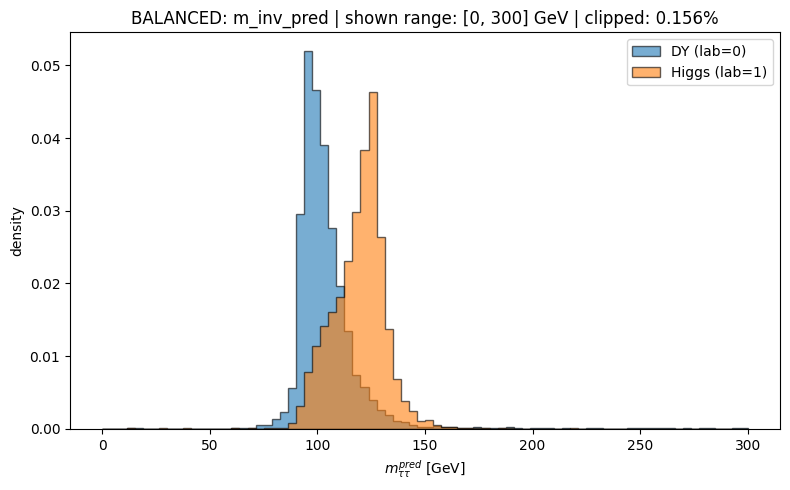

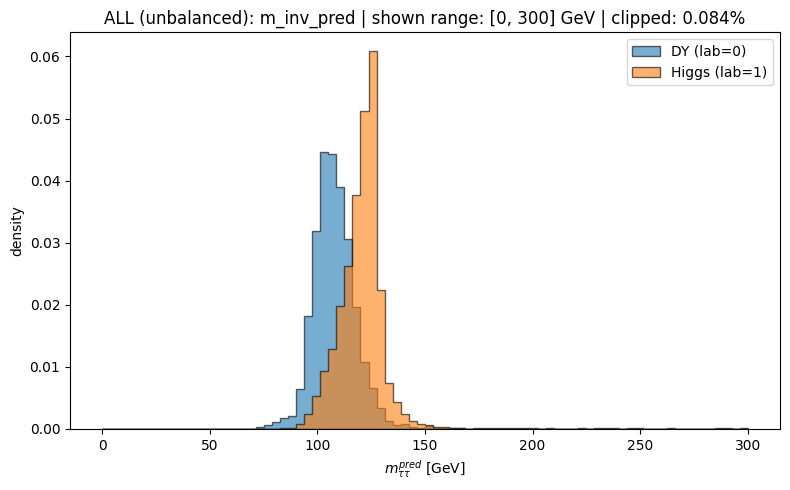

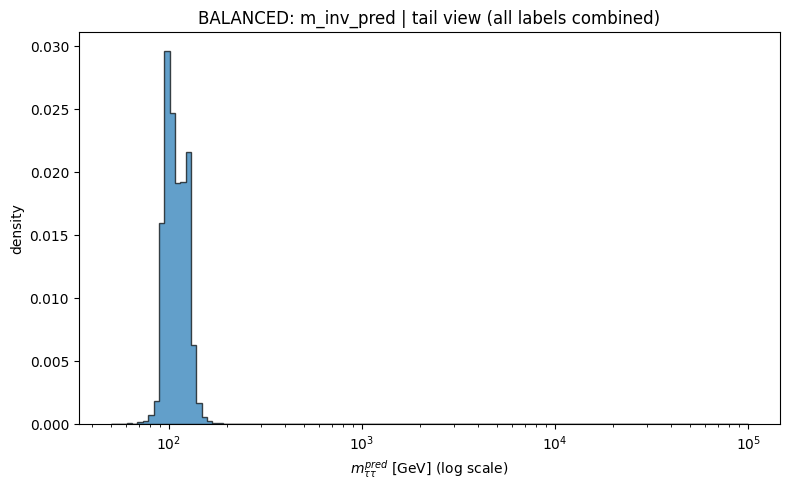

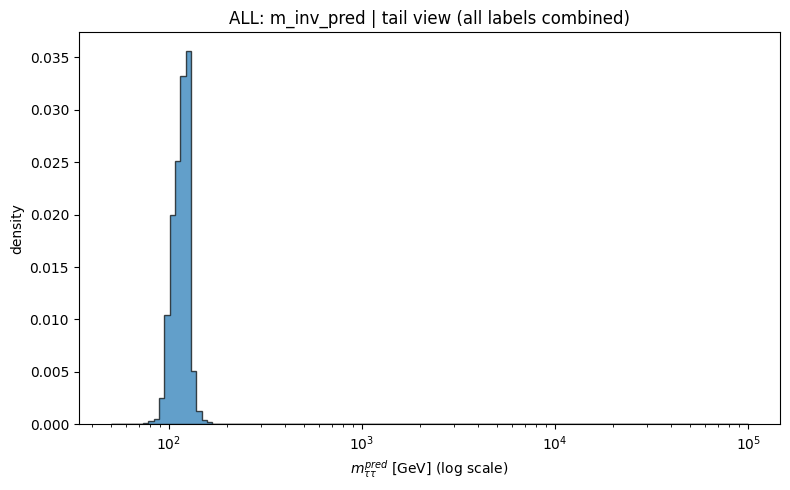

In [91]:
def plot_mass_hist(out, title, mmax=300, bins=80):
    m = np.asarray(out["m_inv_pred"])
    lab = np.asarray(out["lab"])

    # basic cleaning (finite only)
    finite = np.isfinite(m)
    m = m[finite]
    lab = lab[finite]

    # clip for visualization (report fraction outside range)
    inrange = (m >= 0) & (m <= mmax)
    frac_clipped = 1.0 - np.mean(inrange)

    m_dy = m[(lab == 0) & inrange]
    m_h  = m[(lab == 1) & inrange]

    plt.figure(figsize=(8,5))
    plt.hist(m_dy, histtype = 'stepfilled', bins=bins, range=(0, mmax), density=True, alpha=0.6, label="DY (lab=0)", edgecolor='black')
    plt.hist(m_h, histtype = 'stepfilled',  bins=bins, range=(0, mmax), density=True, alpha=0.6, label="Higgs (lab=1)", edgecolor='black')
    plt.xlabel(r"$m_{\tau\tau}^{pred}$ [GeV]")
    plt.ylabel("density")
    plt.title(f"{title} | shown range: [0, {mmax}] GeV | clipped: {frac_clipped*100:.3f}%")
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_mass_log_tail(out, title, mmin=50, mmax=1e5, bins=120):
    """
    Tail-focused view (log-x). Useful to see the rare crazy outliers.
    """
    m = np.asarray(out["m_inv_pred"])
    finite = np.isfinite(m) & (m > 0)
    m = m[finite]

    # log-spaced bins
    edges = np.logspace(np.log10(mmin), np.log10(mmax), bins)
    plt.figure(figsize=(8,5))
    plt.hist(m, histtype = 'stepfilled', bins=edges, density=True, alpha=0.7, edgecolor='black')
    plt.xscale("log")
    plt.xlabel(r"$m_{\tau\tau}^{pred}$ [GeV] (log scale)")
    plt.ylabel("density")
    plt.title(title + " | tail view (all labels combined)")
    plt.tight_layout()
    plt.show()

# --- Plots ---
plot_mass_hist(out_bal, "BALANCED: m_inv_pred", mmax=300, bins=80)
plot_mass_hist(out_all, "ALL (unbalanced): m_inv_pred", mmax=300, bins=80)

# Tail/outliers diagnostics
plot_mass_log_tail(out_bal, "BALANCED: m_inv_pred", mmin=50, mmax=1e5, bins=120)
plot_mass_log_tail(out_all, "ALL: m_inv_pred", mmin=50, mmax=1e5, bins=120)



In [92]:
# Ora calcolo S/B nella finestra ±3sigma.
# Obiettivo : data la mia m_pred, quanto segnale Higgs riesco a isolare rispetto a DY attorno al picco? 


def compute_SB(out, name=""):
    """
    out: dict with keys
      - m_inv_pred
      - lab (0=DY, 1=Higgs)
    """
    m   = np.asarray(out["m_inv_pred"])
    lab = np.asarray(out["lab"])

    # finite & positive masses only
    ok = np.isfinite(m) & (m > 0)
    m = m[ok]
    lab = lab[ok]

    # --- Higgs-only statistics ---
    m_h = m[lab == 1]
    mu = np.mean(m_h)
    sigma = np.std(m_h)

    lo = mu - 3*sigma
    hi = mu + 3*sigma

    # --- counts in window ---
    in_win = (m >= lo) & (m <= hi)
    S = np.sum(in_win & (lab == 1))
    B = np.sum(in_win & (lab == 0))

    SB = S / B if B > 0 else np.inf
    S_sqrtB = S / np.sqrt(B) if B > 0 else np.inf

    print(f"\n=== {name} ===")
    print(f"Higgs peak μ = {mu:.2f} GeV")
    print(f"Higgs σ      = {sigma:.2f} GeV")
    print(f"Window       = [{lo:.1f}, {hi:.1f}] GeV")
    print(f"S (Higgs)    = {S}")
    print(f"B (DY)       = {B}")
    print(f"S/B          = {SB:.3f}")
    print(f"S/√B         = {S_sqrtB:.3f}")

    return {
        "mu": mu,
        "sigma": sigma,
        "S": S,
        "B": B,
        "S/B": SB,
        "S/sqrt(B)": S_sqrtB,
        "window": (lo, hi)
    }

# ---- apply ----
sb_bal = compute_SB(out_bal, name="BALANCED")
sb_all = compute_SB(out_all, name="ALL")



=== BALANCED ===
Higgs peak μ = 119.90 GeV
Higgs σ      = 52.25 GeV
Window       = [-36.9, 276.7] GeV
S (Higgs)    = 5141
B (DY)       = 5123
S/B          = 1.004
S/√B         = 71.827

=== ALL ===
Higgs peak μ = 124.90 GeV
Higgs σ      = 525.76 GeV
Window       = [-1452.4, 1702.2] GeV
S (Higgs)    = 12802
B (DY)       = 5143
S/B          = 2.489
S/√B         = 178.513


In [94]:
# I risultati non sono buoni -> il problema è la definizione di sigma? Provo con un'alternativa :

def compute_SB_robust(out, name=""):
    m   = np.asarray(out["m_inv_pred"])
    lab = np.asarray(out["lab"])

    ok = np.isfinite(m) & (m > 0)
    m = m[ok]
    lab = lab[ok]

    # Higgs only
    m_h = m[lab == 1]

    mu = np.median(m_h)
    p16 = np.percentile(m_h, 16)
    p84 = np.percentile(m_h, 84)
    sigma_rob = 0.5 * (p84 - p16)

    lo = mu - 3*sigma_rob
    hi = mu + 3*sigma_rob

    in_win = (m >= lo) & (m <= hi)
    S = np.sum(in_win & (lab == 1))
    B = np.sum(in_win & (lab == 0))

    SB = S / B if B > 0 else np.inf
    S_sqrtB = S / np.sqrt(B) if B > 0 else np.inf

    print(f"\n=== {name} (ROBUST) ===")
    print(f"Higgs median μ = {mu:.2f} GeV")
    print(f"σ_rob          = {sigma_rob:.2f} GeV")
    print(f"Window         = [{lo:.1f}, {hi:.1f}] GeV")
    print(f"S (Higgs)      = {S}")
    print(f"B (DY)         = {B}")
    print(f"S/B            = {SB:.3f}")
    print(f"S/√B           = {S_sqrtB:.3f}")

    return {
        "mu": mu,
        "sigma_rob": sigma_rob,
        "S": S,
        "B": B,
        "S/B": SB,
        "S/sqrt(B)": S_sqrtB,
        "window": (lo, hi)
    }

sb_bal_rob = compute_SB_robust(out_bal, name="BALANCED")
sb_all_rob = compute_SB_robust(out_all, name="ALL")

# Tengo a mente però che S/B nel caso ALL è dominato dalla composizione del dataset (più Higgs che DY)


=== BALANCED (ROBUST) ===
Higgs median μ = 120.92 GeV
σ_rob          = 11.43 GeV
Window         = [86.6, 155.2] GeV
S (Higgs)      = 5103
B (DY)         = 4958
S/B            = 1.029
S/√B           = 72.472

=== ALL (ROBUST) ===
Higgs median μ = 121.61 GeV
σ_rob          = 8.05 GeV
Window         = [97.5, 145.8] GeV
S (Higgs)      = 12504
B (DY)         = 4496
S/B            = 2.781
S/√B           = 186.482


In [95]:
# Ora : KL_div
from scipy.special import kl_div

def kl_from_hist(p_counts, q_counts, eps=1e-12):
    """
    p_counts, q_counts: conteggi per bin (non normalizzati)
    ritorna D_KL(P||Q) con smoothing eps
    """
    p = p_counts.astype(np.float64)
    q = q_counts.astype(np.float64)

    # smoothing per evitare zeri
    p = p + eps
    q = q + eps

    # normalizza a pdf discreta
    p = p / p.sum()
    q = q / q.sum()

    # scipy.special.kl_div fa: p * log(p/q) - p + q
    # quindi per ottenere p*log(p/q) sommo e tolgo il termine (-p+q) che integra a 0 se p e q sono normalizzate.
    # In pratica: sum(kl_div(p,q)) == sum(p*log(p/q))  (entro errore numerico)
    return float(np.sum(kl_div(p, q)))

def compute_KL_mass(out, name="", mmin=0, mmax=300, bins=80, eps=1e-12):
    m   = np.asarray(out["m_inv_pred"])
    lab = np.asarray(out["lab"])  # 0 DY, 1 Higgs

    ok = np.isfinite(m) & (m > 0)
    m = m[ok]
    lab = lab[ok]

    # range di confronto (per evitare che gli outlier dominino tutto)
    inrange = (m >= mmin) & (m <= mmax)
    frac_clipped = 1.0 - np.mean(inrange)

    m = m[inrange]
    lab = lab[inrange]

    m_h  = m[lab == 1]
    m_dy = m[lab == 0]

    # istogrammi con stessi bin
    edges = np.linspace(mmin, mmax, bins+1)
    h_counts, _  = np.histogram(m_h,  bins=edges)
    dy_counts, _ = np.histogram(m_dy, bins=edges)

    KL_H_DY  = kl_from_hist(h_counts, dy_counts, eps=eps)   # D_KL(H || DY)
    KL_DY_H  = kl_from_hist(dy_counts, h_counts, eps=eps)   # D_KL(DY || H)
    KL_sym   = 0.5*(KL_H_DY + KL_DY_H)

    print(f"\n=== {name} KL on m_inv_pred ===")
    print(f"Range used: [{mmin}, {mmax}] GeV | bins={bins} | clipped(outside range)={frac_clipped*100:.3f}%")
    print(f"Counts in range: Higgs={len(m_h)} | DY={len(m_dy)}")
    print(f"KL(H || DY) = {KL_H_DY:.6f}")
    print(f"KL(DY || H) = {KL_DY_H:.6f}")
    print(f"KL_sym      = {KL_sym:.6f}")

    return {"KL_H_DY": KL_H_DY, "KL_DY_H": KL_DY_H, "KL_sym": KL_sym, "clipped": frac_clipped}

kl_bal = compute_KL_mass(out_bal, name="BALANCED", mmin=0, mmax=300, bins=80, eps=1e-12)
kl_all = compute_KL_mass(out_all, name="ALL",      mmin=0, mmax=300, bins=80, eps=1e-12)



=== BALANCED KL on m_inv_pred ===
Range used: [0, 300] GeV | bins=80 | clipped(outside range)=0.156%
Counts in range: Higgs=5141 | DY=5128
KL(H || DY) = 1.102458
KL(DY || H) = 1.199287
KL_sym      = 1.150872

=== ALL KL on m_inv_pred ===
Range used: [0, 300] GeV | bins=80 | clipped(outside range)=0.084%
Counts in range: Higgs=12801 | DY=5130
KL(H || DY) = 0.931321
KL(DY || H) = 1.099058
KL_sym      = 1.015190
